# 01f · Separación BCG/ICL — API de TNG (halo FoF) recortado a R₂₀₀c

**Objetivo:** replicar el análisis de `01e_` (FoF sin satélites + corte esférico R₂₀₀c)
descargando las partículas vía la **API web de TNG** en vez de leer los archivos de
snapshot locales — igual que `01d_` hace para `01b_`.

| Notebook | Fuente | Partículas incluidas |
|----------|--------|----------------------|
| `01b_` | `loadHalo(fof_idx)` local + máscara | Central + no ligadas (todo el FoF) |
| `01d_` | API cutout **halo** + máscara | Ídem 01b_, vía API |
| `01e_` | `loadHalo(fof_idx)` local + máscara + corte R₂₀₀c | Central + no ligadas, solo dentro de R₂₀₀c |
| **`01f_`** | **API cutout del halo + máscara + corte R₂₀₀c** | **Ídem 01e_, vía API** |

---

## ⚠ Diferencia crucial: cutout de subhalo vs cutout de halo FoF

```python
# INCORRECTO para este análisis — cutout de SUBHALO (solo partículas ligadas al BCG):
sub_prog_url = "https://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/" + '0' + '/'
# Equivale a loadSubhalo(...) → igual que 01_ (NO igual que 01b_/01e_)

# CORRECTO — cutout del HALO FoF completo (central + satélites + no ligadas):
halo_url = "https://www.tng-project.org/api/TNG100-1/snapshots/99/halos/" + '0' + '/'
# Equivale a loadHalo(...) → igual que 01b_/01e_, luego aplicamos la máscara de satélites
```

Este notebook usa `halos/{FOF_IDX}/cutout.hdf5` (no `subhalos/`), analiza **un solo cúmulo**
(sin el loop sobre todo el catálogo — eso ya lo hace `01e_` localmente) y agrega el mismo
corte esférico `r_3d <= R200c` que `01e_`.

In [13]:
import sys, os, pickle, time
import numpy as np
import h5py
import requests
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from scipy.interpolate import interp1d
from scipy.stats import binned_statistic_2d
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, './original_shift_code')
import illustris_python as il
import Catalogue
import params_icl as P

FIG_PDF = './figuras/01f_api_tng_BCG_ICL_R200/pdf'
FIG_PNG = './figuras/01f_api_tng_BCG_ICL_R200/png'
os.makedirs(FIG_PDF, exist_ok=True)
os.makedirs(FIG_PNG, exist_ok=True)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110,
                     'font.size': 12,
                     'axes.spines.top': False,
                     'axes.spines.right': False})

cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)


## Configuración — API key y grupo a analizar

In [14]:
# ── Parámetros principales ──────────────────────────────────────────────
API_KEY   = "4fc61d9b3796c16ec02f0299703478ef"   # ← tu clave de https://www.tng-project.org/users/profile/
GROUP_IDX = 0                   # ← posición en el catálogo ICL local (0-based)
# ────────────────────────────────────────────────────────────────────────

BASE_URL = "https://www.tng-project.org/api/TNG100-1"
SNAP     = P.SNAP   # 99

# Carpeta local donde se guarda el cutout descargado
CUTOUT_DIR = './tng_data'
os.makedirs(CUTOUT_DIR, exist_ok=True)


## Funciones de la API

In [15]:
def api_get(url, params=None):
    """
    GET a la API de TNG. Devuelve JSON si el Content-Type es JSON,
    o el objeto Response completo si es binario (para cutouts HDF5).
    """
    headers = {"api-key": API_KEY}
    r = requests.get(url, headers=headers, params=params, stream=True)
    r.raise_for_status()
    if 'application/json' in r.headers.get('Content-Type', ''):
        return r.json()
    return r


def download_cutout(url, params, local_path, overwrite=False):
    """
    Descarga un cutout HDF5 de la API y lo guarda en local_path.
    Si ya existe y overwrite=False, lo reutiliza (evita descargas repetidas).

    Retorna la ruta del archivo guardado.
    """
    if os.path.exists(local_path) and not overwrite:
        print(f"  Reutilizando cutout local: {local_path}")
        return local_path

    print(f"  Descargando: {url}")
    r = api_get(url, params=params)

    with open(local_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=1024*1024):
            f.write(chunk)

    size_mb = os.path.getsize(local_path) / 1e6
    print(f"  Guardado ({size_mb:.1f} MB): {local_path}")
    return local_path


# Test rápido de conexión
try:
    resp = api_get(f"{BASE_URL}/")
    print(f"Conexión OK — simulación: {resp.get('name', '?')}")
    print(f"  Snapshots disponibles: {resp.get('num_snapshots', '?')}")
except Exception as e:
    print(f"[ERROR] No se pudo conectar a la API: {e}")
    print("  Revisa tu API_KEY y tu conexión a internet.")


Conexión OK — simulación: TNG100-1
  Snapshots disponibles: 100


## Cargar catálogo local y obtener FOF_IDX, M200c, R200c

In [16]:
with h5py.File(P.CATALOG_OUT, 'r') as f:
    group_idx_cat   = f['group_idx'][:]
    M200c_all       = f['M200c_Msun'][:]
    R200c_all       = f['R200c_kpc'][:]
    GroupPos_all    = f['GroupPos_kpc'][:]
    bcg_sub_all     = f['bcg_sub_idx'][:]
    icl_frac_r200_all = f['icl_frac_r200'][:] if 'icl_frac_r200' in f else None

FOF_IDX  = int(group_idx_cat[GROUP_IDX])
M200c    = M200c_all[GROUP_IDX]
R200c    = R200c_all[GROUP_IDX]
GroupPos = GroupPos_all[GROUP_IDX]
BCG_sub  = int(bcg_sub_all[GROUP_IDX])

print(f"Grupo seleccionado (GROUP_IDX={GROUP_IDX}):")
print(f"  FOF_IDX TNG    : {FOF_IDX}")
print(f"  BCG subfind ID : {BCG_sub}")
print(f"  log M200c      : {np.log10(M200c):.2f} M_sun")
print(f"  R200c          : {R200c:.1f} kpc")


Grupo seleccionado (GROUP_IDX=0):
  FOF_IDX TNG    : 0
  BCG subfind ID : 0
  log M200c      : 14.58 M_sun
  R200c          : 1523.0 kpc


## Cargar metadatos del halo desde archivos locales

`GroupFirstSub`, `GroupNsubs` y `SubhaloLenType` no están disponibles de forma fiable en la
respuesta JSON de la API (igual que en `01d_`). Los cargamos directamente desde los archivos
locales con `illustris_python`; la API solo se usa para descargar el cutout de partículas.

In [17]:
# ── GroupFirstSub, GroupNsubs y BoxSize desde archivos locales ──────────
halo_fields = il.groupcat.loadHalos(P.basePath, P.SNAP,
                                     fields=['GroupFirstSub', 'GroupNsubs'])
first_sub = int(halo_fields['GroupFirstSub'][FOF_IDX])
n_subs    = int(halo_fields['GroupNsubs'][FOF_IDX])

header  = il.groupcat.loadHeader(P.basePath, P.SNAP)
box_kpc = header['BoxSize'] * P.UL   # ckpc/h → kpc físicos

print(f"Halo FoF {FOF_IDX} (cargado localmente):")
print(f"  GroupFirstSub : {first_sub}")
print(f"  GroupNsubs    : {n_subs}")
print(f"  BoxSize       : {box_kpc:.1f} kpc")

# ── SubhaloLenType: una sola carga global + slicing ─────────────────────
# Más rápido que N llamadas a la API — y sin rate-limit
all_lens = il.groupcat.loadSubhalos(P.basePath, P.SNAP,
                                     fields=['SubhaloLenType'])
if all_lens.ndim == 1:
    all_lens = all_lens.reshape(-1, 6)

lens_star = all_lens[first_sub : first_sub + n_subs, 4].astype(int)

print(f"\nSubhaloLenType[4] (estrellas) cargado localmente:")
print(f"  Total en subhalos : {lens_star.sum():,}")
print(f"  Central (sub 0)   : {lens_star[0]:,}")
print(f"  Satélites (1..N-1): {lens_star[1:].sum():,}")


Halo FoF 0 (cargado localmente):
  GroupFirstSub : 0
  GroupNsubs    : 17185
  BoxSize       : 110717.4 kpc

SubhaloLenType[4] (estrellas) cargado localmente:
  Total en subhalos : 11,810,749
  Central (sub 0)   : 3,987,343
  Satélites (1..N-1): 7,823,406


## Descargar cutout del **halo** FoF (no del subhalo)

Usamos `halos/{FOF_IDX}/cutout.hdf5` — equivalente a `loadHalo(...)` en local (central +
satélites + no ligadas). El endpoint `subhalos/{id}/cutout.hdf5` traería **solo** las
partículas ligadas al subhalo central (equivalente a `loadSubhalo`, igual a `01_`, **no**
a `01b_`/`01e_`), así que no lo usamos aquí.

Centramos inmediatamente en la posición del BCG (`GroupPos`) para poder aplicar después
el corte esférico en R₂₀₀c.

In [18]:
def Distance_1D(X, X_POS, BoxSize):
    """Distancia periódica 1D entre X y X_POS, considerando una caja periódica de tamaño BoxSize."""
    D = X - X_POS
    D = np.where(D >  BoxSize/2, D - BoxSize, D)
    D = np.where(D < -BoxSize/2, D + BoxSize, D)
    return D


cutout_fields = 'Coordinates,Masses,GFM_StellarPhotometrics'

# URL del cutout del HALO FoF completo (NO subhalos/)
cutout_url   = f"{BASE_URL}/snapshots/{SNAP}/halos/{FOF_IDX}/cutout.hdf5"
cutout_local = f"{CUTOUT_DIR}/cutout_halo_{FOF_IDX}_snap{SNAP}.hdf5"

cutout_path = download_cutout(
    cutout_url,
    params={'stars': cutout_fields},
    local_path=cutout_local,
    overwrite=False   # ← True para forzar re-descarga
)

# Leer el archivo HDF5 descargado
with h5py.File(cutout_path, 'r') as f:
    keys         = list(f['PartType4'].keys())
    pos_raw_ckpc = f['PartType4']['Coordinates'][:]              # ckpc/h
    mass_raw     = f['PartType4']['Masses'][:]                   # 1e10 M_sun/h
    phot_raw     = f['PartType4']['GFM_StellarPhotometrics'][:]  # mag Vega/AB

# Convertir unidades y centrar en el BCG (periodicidad incluida)
pos_kpc  = Distance_1D(pos_raw_ckpc, 0, P.L_BOX) * P.UL   # ckpc/h → kpc físicos
pos_c    = Catalogue.Distance_3D(pos_kpc, GroupPos, box_kpc)
mass_raw = mass_raw * P.UM     # M_sun

if phot_raw.ndim == 1:
    phot_raw = phot_raw.reshape(-1, 8)

n_fof_total = len(mass_raw)
print(f"\nPartículas estelares en el cutout FoF: {n_fof_total:,}")
print(f"Campos disponibles en PartType4: {keys}")


  Reutilizando cutout local: ./tng_data/cutout_halo_0_snap99.hdf5

Partículas estelares en el cutout FoF: 11,816,696
Campos disponibles en PartType4: ['Coordinates', 'GFM_StellarPhotometrics', 'Masses']


## Construir máscara de satélites (con opción exclude_satellites) — idéntica a `01e_`

Las partículas en el cutout del FoF están ordenadas igual que en los archivos locales:
`[subhalo 0] [subhalo 1] ... [subhalo N-1] [no ligadas]`.

In [19]:
def mask_from_lens(lens_star, n_total_fof, exclude_satellites=True):
    """
    Máscara booleana: True = subhalo 0 (central) + partículas no ligadas
    (+ satélites si exclude_satellites=False).
    False = subhalos satélites 1..N-1 (solo si exclude_satellites=True).
    Función idéntica a la de 01b_/01d_/01e_.
    """
    if not exclude_satellites:
        return np.ones(n_total_fof, dtype=bool)
    mask = np.zeros(n_total_fof, dtype=bool)
    n_central = int(lens_star[0]) if len(lens_star) > 0 else n_total_fof
    mask[:n_central] = True
    total_in_subhalos = int(lens_star.sum())
    if total_in_subhalos < n_total_fof:
        mask[total_in_subhalos:] = True
    return mask


EXCLUDE_SATELLITES = False   # False = conserva satélites (comparar con 01d_)

mask_sat = mask_from_lens(lens_star, n_fof_total, exclude_satellites=EXCLUDE_SATELLITES)

n_central = int(lens_star[0])
n_sat     = int(lens_star[1:].sum())
n_unbound = mask_sat.sum() - n_central

print(f"exclude_satellites = {EXCLUDE_SATELLITES}")
print(f"Desglose de partículas (cutout API):")
print(f"  Total FoF                          : {n_fof_total:>9,}")
print(f"  Subhalo central                    : {n_central:>9,}  (conservadas)")
print(f"  Satélites {'(excluidos)' if EXCLUDE_SATELLITES else '(incluidos) '}          : {n_sat:>9,}")
print(f"  No ligadas                         : {n_unbound:>9,}  (conservadas — ICL difusa)")
print(f"  BCG (+ satélites si aplica)        : {mask_sat.sum():>9,}")


exclude_satellites = False
Desglose de partículas (cutout API):
  Total FoF                          : 11,816,696
  Subhalo central                    : 3,987,343  (conservadas)
  Satélites (incluidos)           : 7,823,406
  No ligadas                         : 7,829,353  (conservadas — ICL difusa)
  BCG (+ satélites si aplica)        : 11,816,696


## Corte esférico en R₂₀₀c — idéntico a `01e_`

Se descarta todo lo que quede fuera de `r_3d <= R200c` respecto al BCG, sobre la máscara
de satélites ya aplicada.

In [20]:
r_3d      = np.linalg.norm(pos_c, axis=1)
mask_r200 = r_3d <= R200c

# incluir corte en R200
#mask_final = mask_sat & mask_r200

# sin incluir el corte en R200
mask_final = mask_sat


n_excl_r200 = mask_sat.sum() - mask_final.sum()

print(f"  Excluidas por R₂₀₀c (R={R200c:.0f} kpc) : {n_excl_r200:>9,}")
print(f"  Usadas para perfil (01f_)              : {mask_final.sum():>9,}")

# Aplicar máscara final y calcular luminosidades
pos  = pos_c[mask_final]
mass = mass_raw[mask_final]
phot = phot_raw[mask_final]
# índice 1 = B-band (Johnson, Vega) en GFM_StellarPhotometrics (U,B,V,K,g,r,i,z)
lum_b = 10**((P.M_SUN_B_VEGA - phot[:, 1]) / 2.5)


  Excluidas por R₂₀₀c (R=1523 kpc) :         0
  Usadas para perfil (01f_)              : 11,816,696


## Funciones auxiliares — idénticas a `01b_`/`01e_`

In [21]:
def rotate_by_inertia_tensor(pos_rel, mass, r_lim=np.inf):
    """Alinea las partículas con los ejes principales del tensor de inercia reducido."""
    dist = np.linalg.norm(pos_rel, axis=1)
    ok   = (dist > 0) & (dist <= r_lim) & np.isfinite(mass)
    p, m = pos_rel[ok], mass[ok]

    if m.sum() == 0 or len(m) < 4:
        return pos_rel, np.eye(3)

    w    = 1.0 / dist[ok]**2
    mtot = np.sum(m)
    Ixx  = np.sum(m * p[:,0]**2 * w) / mtot
    Iyy  = np.sum(m * p[:,1]**2 * w) / mtot
    Izz  = np.sum(m * p[:,2]**2 * w) / mtot
    Ixy  = np.sum(m * p[:,0] * p[:,1] * w) / mtot
    Ixz  = np.sum(m * p[:,0] * p[:,2] * w) / mtot
    Iyz  = np.sum(m * p[:,1] * p[:,2] * w) / mtot
    I = np.array([[Ixx, Ixy, Ixz],
                  [Ixy, Iyy, Iyz],
                  [Ixz, Iyz, Izz]])

    eigvals, eigvecs = np.linalg.eigh(I)
    idx     = np.argsort(eigvals)[::-1]
    R_mat   = eigvecs[:, idx].T
    pos_rot = pos_rel @ R_mat.T
    return pos_rot, R_mat


def sb_profile_b(r_2d, lum_b, r_max_kpc, n_bins=60):
    """Perfil 1D de brillo superficial en banda B (Johnson, Vega)."""
    r_bins = np.logspace(np.log10(0.5), np.log10(r_max_kpc), n_bins + 1)
    r_mid  = np.sqrt(r_bins[:-1] * r_bins[1:])
    mu_b   = np.full(n_bins, np.nan)

    for k, (r1, r2) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mk = (r_2d >= r1) & (r_2d < r2)
        if mk.sum() == 0:
            continue
        area_pc2 = np.pi * ((r2 * 1e3)**2 - (r1 * 1e3)**2)
        sigma_L  = lum_b[mk].sum() / area_pc2
        if sigma_L > 0:
            mu_b[k] = P.SB_CONST - 2.5 * np.log10(sigma_L)

    return r_mid, mu_b


def holmberg_radius(r_mid, mu_b, mu_cut=P.MU_HOLMBERG):
    """Interpola el radio donde μ_B = mu_cut."""
    valid = np.isfinite(mu_b) & (r_mid > 0)
    if valid.sum() < 3:
        return np.nan
    r_v, m_v = r_mid[valid], mu_b[valid]
    idx_s = np.argsort(r_v)
    r_v, m_v = r_v[idx_s], m_v[idx_s]
    if m_v[0] > mu_cut or m_v[-1] < mu_cut:
        return np.nan
    try:
        f = interp1d(m_v, r_v, kind='linear', fill_value='extrapolate')
        r_h = float(f(mu_cut))
        return r_h if 0 < r_h <= r_v[-1] * 1.2 else np.nan
    except Exception:
        return np.nan


## Análisis: perfil de Holmberg y separación BCG/ICL (R₂₀₀c)

In [22]:
pos_rot, R_mat = rotate_by_inertia_tensor(pos, mass)
r_2d = np.sqrt(pos_rot[:, 0]**2 + pos_rot[:, 1]**2)

r_max       = np.percentile(r_2d, 99)
r_mid, mu_b = sb_profile_b(r_2d, lum_b, r_max)
r_h         = holmberg_radius(r_mid, mu_b)

M_bcg = mass[r_2d <= r_h].sum()
M_icl = mass[r_2d >  r_h].sum()
f_icl = M_icl / (M_bcg + M_icl)

print(f"Radio de Holmberg      : {r_h:.1f} kpc")
print(f"M_BCG                  : {M_bcg:.3e} M_sun  (log = {np.log10(M_bcg):.2f})")
print(f"M_ICL                  : {M_icl:.3e} M_sun  (log = {np.log10(M_icl):.2f})")
print(f"f_ICL (API, R₂₀₀c)     : {f_icl:.4f}")

# Comparar con 01e_ (mismo grupo, calculado localmente con corte R200c)
if icl_frac_r200_all is not None:
    f_icl_01e = icl_frac_r200_all[GROUP_IDX]
    print(f"\nComparación con 01e_ (local, mismo corte R₂₀₀c):")
    print(f"  f_ICL_R200 (01e_ local) : {f_icl_01e:.4f}")
    print(f"  f_ICL_R200 (01f_ API)   : {f_icl:.4f}")
    print(f"  Δ                       : {abs(f_icl - f_icl_01e):.4f}")
    print("  (deberían ser idénticos si el cutout API = loadHalo local)")
else:
    print("\nNo se encontró 'icl_frac_r200' en el catálogo. Corre primero 01e_.")


Radio de Holmberg      : 208.5 kpc
M_BCG                  : 3.192e+12 M_sun  (log = 12.50)
M_ICL                  : 7.852e+12 M_sun  (log = 12.89)
f_ICL (API, R₂₀₀c)     : 0.7110

Comparación con 01e_ (local, mismo corte R₂₀₀c):
  f_ICL_R200 (01e_ local) : 0.3096
  f_ICL_R200 (01f_ API)   : 0.7110
  Δ                       : 0.4014
  (deberían ser idénticos si el cutout API = loadHalo local)


### Figura 1 – Perfil de brillo superficial 1D

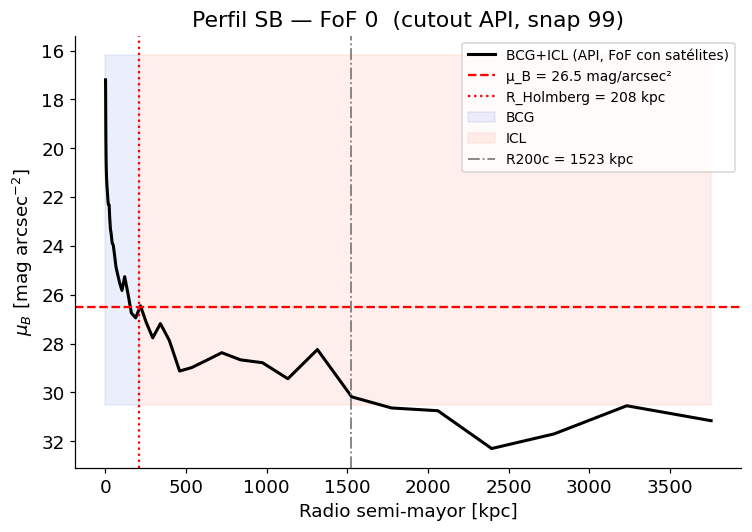

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
valid = np.isfinite(mu_b)

# con satelites y corte R200
#ax.plot(r_mid[valid], mu_b[valid], 'k-', lw=2,
#        label=f'BCG+ICL (API, FoF con satélites, R < R200c={R200c:.0f} kpc)')

# con satelites y sin corte R200
ax.plot(r_mid[valid], mu_b[valid], 'k-', lw=2,
        label=f'BCG+ICL (API, FoF con satélites)')


ax.axhline(P.MU_HOLMBERG, color='r', ls='--', lw=1.5,
           label=f'μ_B = {P.MU_HOLMBERG} mag/arcsec²')
if np.isfinite(r_h):
    ax.axvline(r_h, color='r', ls=':', lw=1.5,
               label=f'R_Holmberg = {r_h:.0f} kpc')
    ax.fill_betweenx([mu_b[valid].min()-1, P.MU_HOLMBERG+4],
                      0, r_h, alpha=0.10, color='royalblue', label='BCG')
    ax.fill_betweenx([mu_b[valid].min()-1, P.MU_HOLMBERG+4],
                      r_h, r_mid[valid][-1], alpha=0.10, color='tomato', label='ICL')
ax.axvline(R200c, color='gray', ls='-.', lw=1.2,
           label=f'R200c = {R200c:.0f} kpc')
ax.invert_yaxis()
ax.set_xlabel('Radio semi-mayor [kpc]')
ax.set_ylabel(r'$\mu_B$ [mag arcsec$^{-2}$]')

# con satelites con corte en R200
#ax.set_title(f'Perfil SB — FoF {FOF_IDX}  (cutout API, snap {SNAP}, recortado a R200c)')

# con satelites, sin corte en R200
ax.set_title(f'Perfil SB — FoF {FOF_IDX}  (cutout API, snap {SNAP})')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01f_perfil_sb_fof{FOF_IDX}_snap{SNAP}.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01f_perfil_sb_fof{FOF_IDX}_snap{SNAP}.png', bbox_inches='tight', dpi=150)
plt.show()


### Figura 2 – Mapa 2D de brillo superficial

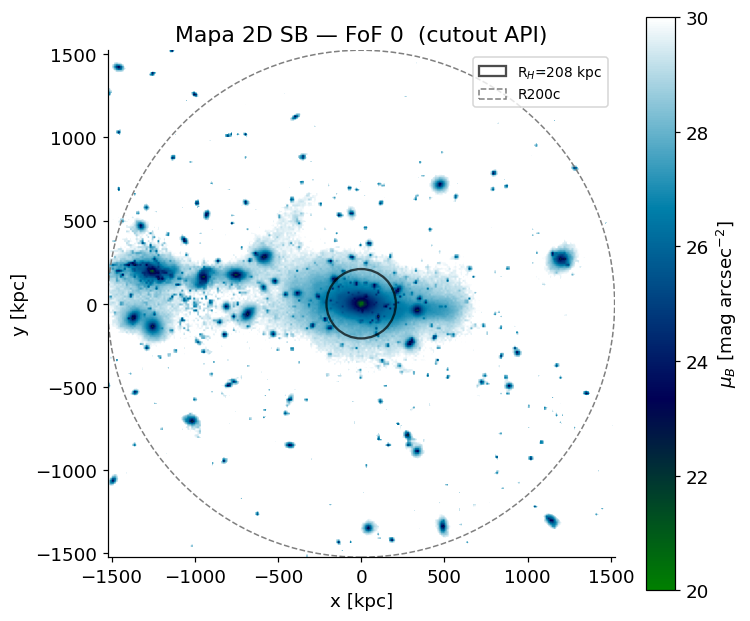

In [12]:
r_plot  = R200c
n_pix   = 256
edges   = np.linspace(-r_plot, r_plot, n_pix + 1)
pix_pc2 = ((2 * r_plot / n_pix) * 1e3)**2

H, _, _, _ = binned_statistic_2d(pos_rot[:, 0], pos_rot[:, 1],
                                   lum_b, statistic='sum',
                                   bins=[edges, edges])
with np.errstate(divide='ignore', invalid='ignore'):
    sigma  = np.where(H > 0, H / pix_pc2, np.nan)
    mu_map = np.where(sigma > 0, P.SB_CONST - 2.5 * np.log10(sigma), np.nan)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(mu_map.T, origin='lower', cmap='ocean',
               extent=[-r_plot, r_plot, -r_plot, r_plot],
               vmin=20, vmax=30)
plt.colorbar(im, ax=ax, label=r'$\mu_B$ [mag arcsec$^{-2}$]')
if np.isfinite(r_h):
    ax.add_patch(plt.Circle((0, 0), r_h, fill=False, color='black',
                              lw=1.5, label=f'R$_H$={r_h:.0f} kpc', alpha=0.7))
ax.add_patch(plt.Circle((0, 0), R200c, fill=False, color='gray',
                          lw=1, ls='--', label='R200c'))
ax.set_xlabel('x [kpc]'); ax.set_ylabel('y [kpc]')

# con satelites corte en R200
#ax.set_title(f'Mapa 2D SB — FoF {FOF_IDX}  (cutout API) - R200 cut')

# con satelites sin corte en R200
ax.set_title(f'Mapa 2D SB — FoF {FOF_IDX}  (cutout API)')


ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIG_PDF}/fig01f_mapa_sb_fof{FOF_IDX}_snap{SNAP}.pdf', bbox_inches='tight')
plt.savefig(f'{FIG_PNG}/fig01f_mapa_sb_fof{FOF_IDX}_snap{SNAP}.png', bbox_inches='tight', dpi=150)
plt.show()